## External Corn Dataset Visualisation

The first part of this notebook loads a representative hyperspectral scene from the independent external corn dataset and produces a mean-intensity grayscale visualisation

In [13]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

EXTERNAL_DATASET_ROOT = Path(
    "/mnt/c/Users/isaac/Downloads/"
    "Hyperspectral_corn_dataset/"
    "Hyperspectral_corn_seed_dataset/"
    "Hyperspectral_corn_seed_dataset"
)


if not EXTERNAL_DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"External dataset not found:\n"
        f"{EXTERNAL_DATASET_ROOT}"
    )


def find_matching_spe_file(header_path):
    """Find the .spe file corresponding to an ENVI .hdr file."""

    expected_path = header_path.with_suffix(".spe")

    if expected_path.exists():
        return expected_path

    matches = [
        candidate
        for candidate in header_path.parent.iterdir()
        if (
            candidate.is_file()
            and candidate.stem.lower() == header_path.stem.lower()
            and candidate.suffix.lower() == ".spe"
        )
    ]

    if len(matches) == 1:
        return matches[0]

    return None


scene_pairs = []

for header_path in sorted(
    EXTERNAL_DATASET_ROOT.rglob("*.hdr")
):
    relative_path = header_path.relative_to(
        EXTERNAL_DATASET_ROOT
    )

    if any(
        part.lower() == "rgb"
        for part in relative_path.parts
    ):
        continue

    spe_path = find_matching_spe_file(
        header_path
    )

    if spe_path is not None:
        scene_pairs.append(
            (
                header_path,
                spe_path
            )
        )


print(
    "Complete hyperspectral scenes found:",
    len(scene_pairs)
)

print(
    "\nFirst scene:"
)

print(
    scene_pairs[0][0]
)

Complete hyperspectral scenes found: 23

First scene:
/mnt/c/Users/isaac/Downloads/Hyperspectral_corn_dataset/Hyperspectral_corn_seed_dataset/Hyperspectral_corn_seed_dataset/Caitiannuo No.6/1.hdr


In [6]:
ENVI_DATA_TYPE_MAP = {
    1: np.uint8,
    2: np.int16,
    3: np.int32,
    4: np.float32,
    5: np.float64,
    6: np.complex64,
    9: np.complex128,
    12: np.uint16,
    13: np.uint32,
    14: np.int64,
    15: np.uint64
}


def parse_envi_header(header_path):
    """Read ENVI metadata and wavelength values."""

    header_text = Path(
        header_path
    ).read_text(
        encoding="latin-1",
        errors="replace"
    )

    metadata = {}

    current_key = None
    current_value_parts = []
    brace_balance = 0

    for raw_line in header_text.splitlines():

        line = raw_line.strip()

        if not line:
            continue

        if (
            current_key is None
            and "=" in line
        ):
            key, value = line.split(
                "=",
                1
            )

            current_key = (
                key.strip().lower()
            )

            current_value_parts = [
                value.strip()
            ]

            brace_balance = (
                value.count("{")
                - value.count("}")
            )

            if brace_balance <= 0:

                metadata[
                    current_key
                ] = " ".join(
                    current_value_parts
                )

                current_key = None
                current_value_parts = []

        elif current_key is not None:

            current_value_parts.append(
                line
            )

            brace_balance += (
                line.count("{")
                - line.count("}")
            )

            if brace_balance <= 0:

                metadata[
                    current_key
                ] = " ".join(
                    current_value_parts
                )

                current_key = None
                current_value_parts = []


    samples = int(
        metadata["samples"]
    )

    lines = int(
        metadata["lines"]
    )

    bands = int(
        metadata["bands"]
    )

    data_type_code = int(
        metadata["data type"]
    )

    interleave = (
        metadata["interleave"]
        .strip()
        .lower()
    )

    byte_order = int(
        metadata.get(
            "byte order",
            "0"
        )
    )

    header_offset = int(
        metadata.get(
            "header offset",
            "0"
        )
    )


    dtype = np.dtype(
        ENVI_DATA_TYPE_MAP[
            data_type_code
        ]
    )

    if dtype.itemsize > 1:

        if byte_order == 0:
            dtype = dtype.newbyteorder("<")

        else:
            dtype = dtype.newbyteorder(">")


    wavelength_text = (
        metadata["wavelength"]
        .replace("{", " ")
        .replace("}", " ")
    )

    wavelengths = np.asarray(
        [
            float(value)
            for value in re.findall(
                r"[-+]?"
                r"(?:\d*\.\d+|\d+\.?)"
                r"(?:[eE][-+]?\d+)?",
                wavelength_text
            )
        ],
        dtype=float
    )


    return {
        "samples": samples,
        "lines": lines,
        "bands": bands,
        "dtype": dtype,
        "interleave": interleave,
        "header_offset": header_offset,
        "wavelengths": wavelengths
    }


def load_external_envi_cube(
    header_path,
    spe_path
):
    """Load one external hyperspectral cube."""

    metadata = parse_envi_header(
        header_path
    )

    lines = metadata["lines"]
    samples = metadata["samples"]
    bands = metadata["bands"]

    interleave = metadata[
        "interleave"
    ]


    if interleave == "bil":

        raw_shape = (
            lines,
            bands,
            samples
        )

    elif interleave == "bip":

        raw_shape = (
            lines,
            samples,
            bands
        )

    else:

        raw_shape = (
            bands,
            lines,
            samples
        )


    raw_cube = np.memmap(
        spe_path,
        dtype=metadata["dtype"],
        mode="r",
        offset=metadata["header_offset"],
        shape=raw_shape
    )


    if interleave == "bil":

        cube = np.transpose(
            raw_cube,
            (0, 2, 1)
        )

    elif interleave == "bip":

        cube = raw_cube

    else:

        cube = np.transpose(
            raw_cube,
            (1, 2, 0)
        )


    cube = np.asarray(
        cube,
        dtype=np.float32
    )


    return (
        cube,
        metadata["wavelengths"]
    )

In [7]:
SCENE_INDEX = 0


header_path, spe_path = (
    scene_pairs[
        SCENE_INDEX
    ]
)


cube, wavelengths = (
    load_external_envi_cube(
        header_path,
        spe_path
    )
)


print(
    "Scene:",
    header_path.name
)

print(
    "Cube shape:",
    cube.shape
)

print(
    "Wavelength range:",
    f"{wavelengths.min():.1f}",
    "-",
    f"{wavelengths.max():.1f}",
    "nm"
)

Scene: 1.hdr
Cube shape: (529, 480, 300)
Wavelength range: 386.5 - 1020.2 nm


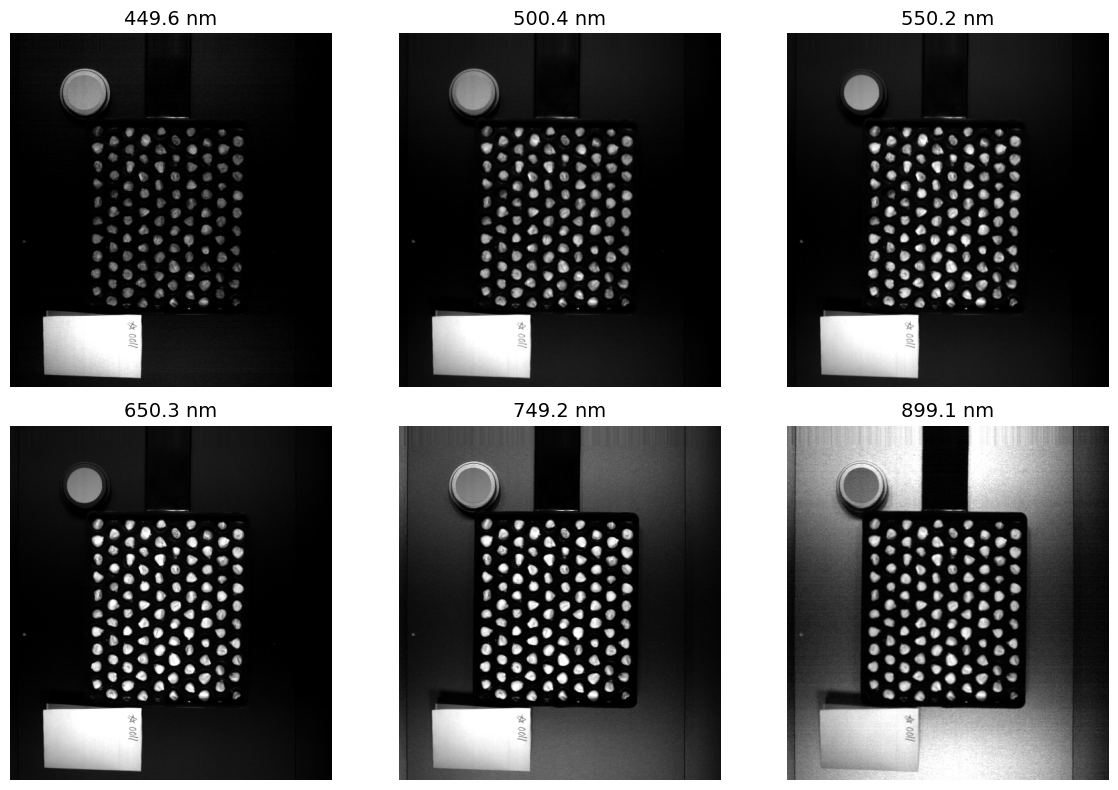

In [8]:
TARGET_WAVELENGTHS = [
    450,
    500,
    550,
    650,
    750,
    900
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)


for ax, target_wavelength in zip(
    axes.ravel(),
    TARGET_WAVELENGTHS
):

    band_index = int(
        np.argmin(
            np.abs(
                wavelengths
                - target_wavelength
            )
        )
    )

    actual_wavelength = (
        wavelengths[
            band_index
        ]
    )

    band_image = cube[
        :,
        :,
        band_index
    ]


    # Robust scaling for display only
    low, high = np.percentile(
        band_image[
            np.isfinite(
                band_image
            )
        ],
        [2, 98]
    )

    display_image = np.clip(
        (
            band_image
            - low
        )
        / (
            high
            - low
            + 1e-8
        ),
        0,
        1
    )


    ax.imshow(
        display_image,
        cmap="gray"
    )

    ax.set_title(
        f"{actual_wavelength:.1f} nm",
        fontsize=14
    )

    ax.axis(
        "off"
    )


plt.tight_layout()
plt.show()

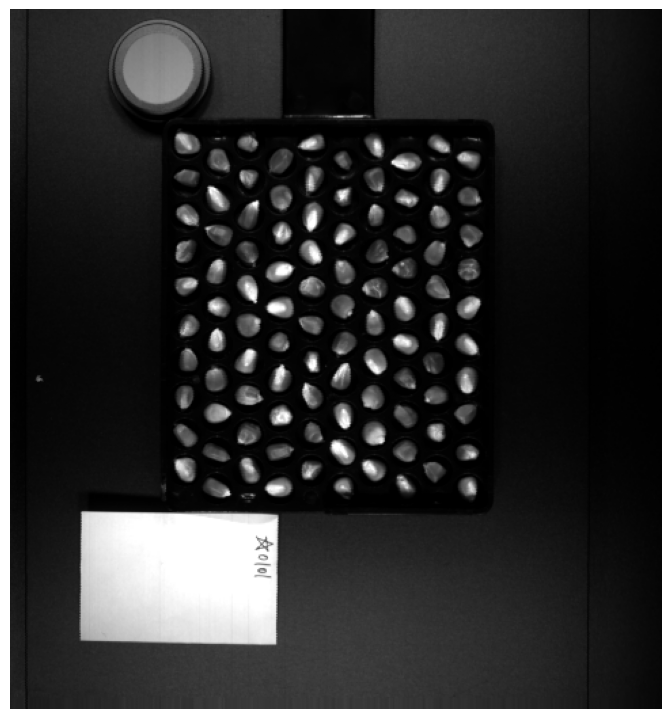

In [11]:
DISPLAY_MIN_NM = 450
DISPLAY_MAX_NM = 900


display_band_mask = (
    (wavelengths >= DISPLAY_MIN_NM)
    & (wavelengths <= DISPLAY_MAX_NM)
)


mean_image = cube[
    :,
    :,
    display_band_mask
].mean(
    axis=2
)


finite_values = mean_image[
    np.isfinite(
        mean_image
    )
]


low, high = np.percentile(
    finite_values,
    [2, 98]
)


display_image = np.clip(
    (
        mean_image
        - low
    )
    / (
        high
        - low
        + 1e-8
    ),
    0,
    1
)


fig, ax = plt.subplots(
    figsize=(7, 7)
)


ax.imshow(
    display_image,
    cmap="gray"
)

ax.axis(
    "off"
)


plt.tight_layout(
    pad=0
)

plt.savefig(
    "external_corn_example.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

## Loss Curve Plots

The second part of this notebook training and validation loss histories of the PCA three-band spatial models (for our main test set, not the external one described above) are reloaded from the saved experiment results and visualised with tighter axis limits to highlight model behaviour after the initial rapid decrease in loss.

In [14]:
# --- Load saved PCA three-band CNN training histories ---
BASE_DIR = Path.cwd()

CUSTOM_HISTORY_FILE = (
    BASE_DIR
    / "spatial_results_custom_cnn_mil"
    / "pca_3_band_cnn_history.csv"
)

RESNET_HISTORY_FILE = (
    BASE_DIR
    / "spatial_results_resnet18_image_level"
    / "final_models"
    / "pca_3_band_cnn_history.csv"
)


if not CUSTOM_HISTORY_FILE.exists():
    raise FileNotFoundError(
        f"Custom CNN history not found:\n"
        f"{CUSTOM_HISTORY_FILE}"
    )

if not RESNET_HISTORY_FILE.exists():
    raise FileNotFoundError(
        f"ResNet18 history not found:\n"
        f"{RESNET_HISTORY_FILE}"
    )


custom_history = pd.read_csv(
    CUSTOM_HISTORY_FILE
)

resnet_history = pd.read_csv(
    RESNET_HISTORY_FILE
)


print(
    "Custom CNN history:",
    CUSTOM_HISTORY_FILE
)

print(
    "Custom CNN epochs:",
    len(custom_history)
)

print()

print(
    "ResNet18 history:",
    RESNET_HISTORY_FILE
)

print(
    "ResNet18 epochs:",
    len(resnet_history)
)

Custom CNN history: /home/isaacmuscat/Grain-Variety-Classification/spatial_results_custom_cnn_mil/pca_3_band_cnn_history.csv
Custom CNN epochs: 43

ResNet18 history: /home/isaacmuscat/Grain-Variety-Classification/spatial_results_resnet18_image_level/final_models/pca_3_band_cnn_history.csv
ResNet18 epochs: 90


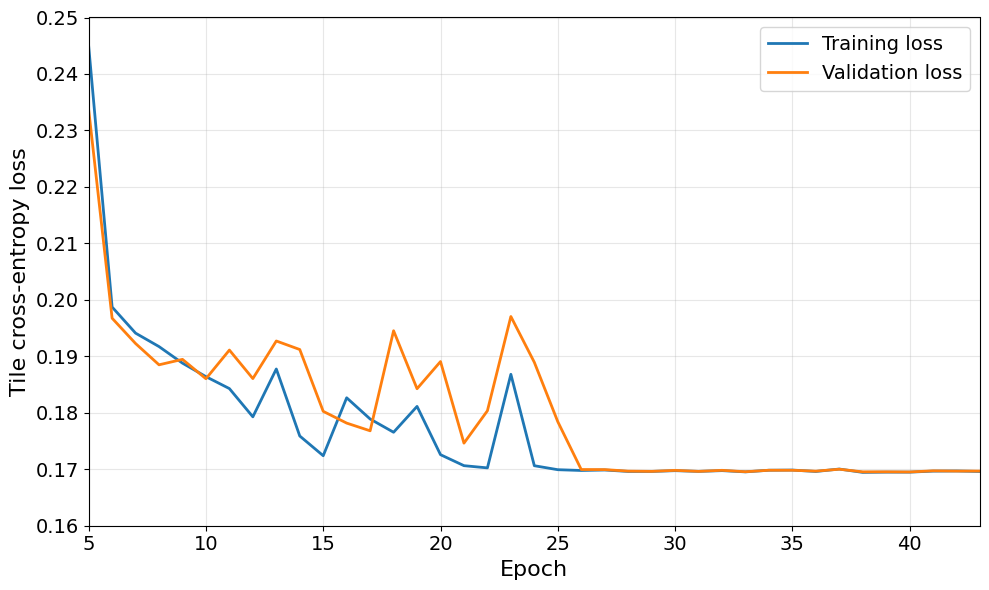

In [15]:
# --- PCA three-band Custom CNN loss curve ---

PLOT_FROM_EPOCH = 5

custom_plot = custom_history[
    custom_history["epoch"]
    >= PLOT_FROM_EPOCH
]


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.plot(
    custom_plot["epoch"],
    custom_plot["train_tile_loss"],
    linewidth=2,
    label="Training loss"
)

ax.plot(
    custom_plot["epoch"],
    custom_plot["valid_tile_loss"],
    linewidth=2,
    label="Validation loss"
)


ax.set_xlabel(
    "Epoch",
    fontsize=16
)

ax.set_ylabel(
    "Tile cross-entropy loss",
    fontsize=16
)

ax.tick_params(
    axis="both",
    labelsize=14
)


# Tightened limits to show stabilisation
ax.set_xlim(
    PLOT_FROM_EPOCH,
    custom_history["epoch"].max()
)

ax.set_ylim(
    0.16,
    0.25
)


ax.legend(
    fontsize=14
)

ax.grid(
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    "pca_3_band_custom_cnn_loss.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

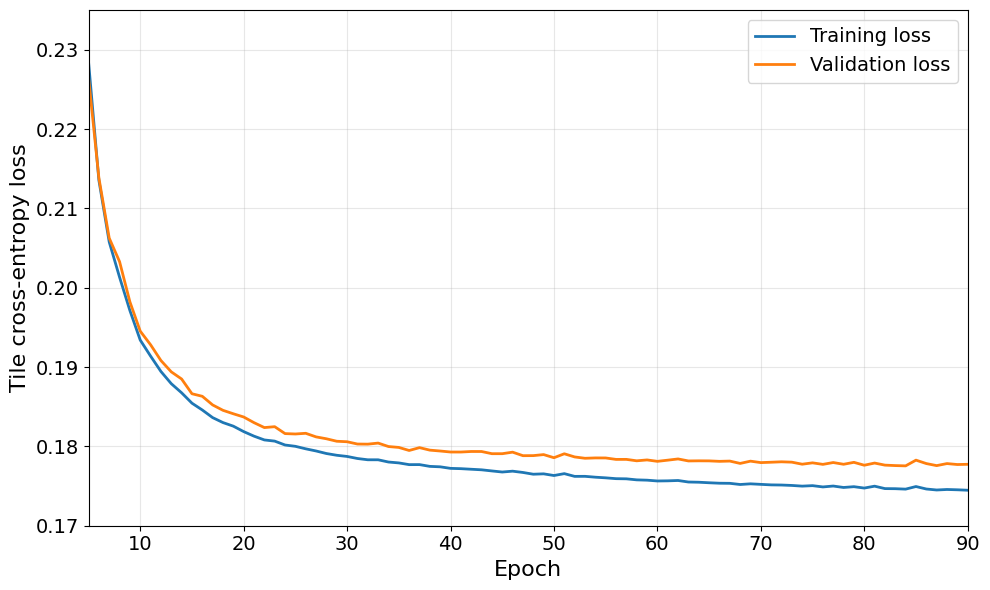

In [16]:
# --- PCA three-band ResNet18 loss curve ---

PLOT_FROM_EPOCH = 5

resnet_plot = resnet_history[
    resnet_history["epoch"]
    >= PLOT_FROM_EPOCH
]


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.plot(
    resnet_plot["epoch"],
    resnet_plot["train_tile_loss"],
    linewidth=2,
    label="Training loss"
)

ax.plot(
    resnet_plot["epoch"],
    resnet_plot["valid_tile_loss"],
    linewidth=2,
    label="Validation loss"
)


ax.set_xlabel(
    "Epoch",
    fontsize=16
)

ax.set_ylabel(
    "Tile cross-entropy loss",
    fontsize=16
)

ax.tick_params(
    axis="both",
    labelsize=14
)


# Tightened limits to show stabilisation
ax.set_xlim(
    PLOT_FROM_EPOCH,
    resnet_history["epoch"].max()
)

ax.set_ylim(
    0.17,
    0.235
)


ax.legend(
    fontsize=14
)

ax.grid(
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    "pca_3_band_resnet18_loss.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()